<a href="https://colab.research.google.com/github/hobbsandbobs-dotcom/Analytics-Coursework/blob/main/3_SQL_and_R_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setting up

In [1]:
import pandas as pd

#Uploading NorthStar's datasets into Colab
from google.colab import files
file_uploaded = files.upload()

Saving vehicles_clean.csv to vehicles_clean.csv
Saving orders_clean.csv to orders_clean.csv
Saving incidents_clean.csv to incidents_clean.csv
Saving hubs_clean.csv to hubs_clean.csv
Saving drivers_clean.csv to drivers_clean.csv
Saving deliveries_clean.csv to deliveries_clean.csv
Saving customers_clean.csv to customers_clean.csv
Saving complaints_clean.csv to complaints_clean.csv
Saving app_events_clean.csv to app_events_clean.csv


In [2]:
#Python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Reloading the cleaned datasets
orders_df = pd.read_csv("orders_clean.csv")
deliveries_df = pd.read_csv("deliveries_clean.csv")
drivers_df = pd.read_csv("drivers_clean.csv")
vehicles_df = pd.read_csv("vehicles_clean.csv")
hubs_df = pd.read_csv("hubs_clean.csv")
incidents_df = pd.read_csv("incidents_clean.csv")
complaints_df = pd.read_csv("complaints_clean.csv")
customers_df = pd.read_csv("customers_clean.csv")
app_events_df = pd.read_csv("app_events_clean.csv")

2. SQL Within R

In [3]:
#had an error so making sure they are the same type
orders_df["order_id"] = orders_df["order_id"].astype("string")
deliveries_df["order_id"] = deliveries_df["order_id"].astype("string")
app_events_df["order_id"] = app_events_df["order_id"].astype("string")
complaints_df["order_id"] = complaints_df["order_id"].astype("string")

3. R within Colab

In [4]:
!pip install rpy2

%load_ext rpy2.ipython

In [5]:

%%R

install.packages(c("sqldf","dplyr", "ggplot2", "ggrepel"), repos="https://cloud.r-project.org")
library(sqldf)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(scales)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’

trying URL 'https://cloud.r-project.org/src/contrib/gsubfn_0.7.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/proto_1.0.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/RSQLite_3.52.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/chron_2.3-62.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/sqldf_0.4-12.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/dplyr_1.2.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/ggplot2_4.0.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/ggrepel_0.9.8.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpIEAdLZ/downloaded_packages’
Loading required package: gsubfn
Loading required package: proto
Loading required package: RSQLite

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:


In [6]:
%%R -i orders_df -i deliveries_df -i customers_df -i incidents_df -i drivers_df -i vehicles_df -i hubs_df -i app_events_df -i complaints_df

NULL


4. SQL Query 1

In [11]:
%%R

delivery_ratings_overview <- sqldf("

SELECT

    ord.priority_level AS service_priority,
    deliv.delivery_status AS delivery_outcome,

    COUNT(DISTINCT deliv.delivery_id)
        AS total_deliveries,
    COUNT(DISTINCT comp.complaint_id)
        AS unique_complaints,

    ROUND(

        COUNT(DISTINCT comp.complaint_id) * 1.0 /

        COUNT(DISTINCT deliv.delivery_id),

        2

    )
        AS complaint_frequency,

    AVG(deliv.customer_rating_post_delivery)
        AS mean_customer_rating,

    AVG(comp.compensation_amount)
        AS mean_compensation,

    SUM(comp.compensation_amount)
        AS total_compensation_cost

FROM orders_df AS ord

LEFT JOIN deliveries_df AS deliv
    ON ord.order_id = deliv.order_id

LEFT JOIN complaints_df AS comp
    ON ord.order_id = comp.order_id

GROUP BY
    ord.priority_level,
    deliv.delivery_status
")


In [12]:
%%R

delivery_ratings_overview

   service_priority delivery_outcome total_deliveries unique_complaints
1          Critical             <NA>                0                 3
2          Critical          Delayed               15                 5
3          Critical           Failed                3                 0
4          Critical           OnTime               56                14
5              High             <NA>                0                26
6              High          Delayed               46                11
7              High           Failed               32                 7
8              High           OnTime              153                36
9               Low             <NA>                0                25
10              Low          Delayed               53                12
11              Low           Failed               34                11
12              Low           OnTime              172                36
13           Medium             <NA>                0           


(`geom_text()`). 



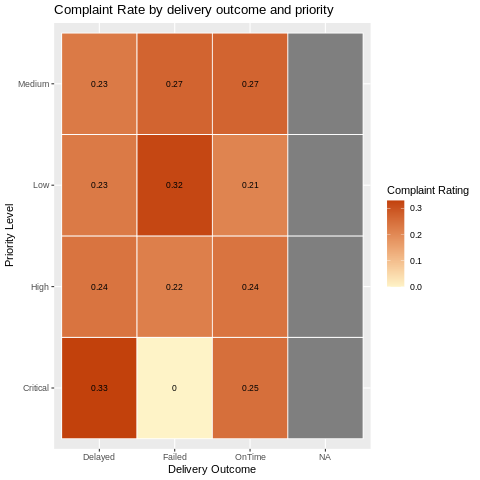

In [21]:
%%R

ggplot(
    delivery_ratings_overview,
    aes(
        x = delivery_outcome,
        y = service_priority,
        fill = complaint_frequency
      )
) +
geom_tile(
    colour = "white",
    linewidth = 0.4
) +

  scale_fill_gradient(
    low = "#FEF3C7",
    high = "#C2410C"
) +

geom_text(
    aes(label = round(complaint_frequency, 2)),
    size = 3
) +


  labs(
    title = "Complaint Rate by delivery outcome and priority",
    x = "Delivery Outcome",
    y = "Priority Level",
    fill = "Complaint Rating"
  )

4.2. R stats

In [ ]:
#NEED TO DETERMINE ONE

5. Query 2

In [72]:
%%R
library(sqldf)

nstar_app_performance <- sqldf("
SELECT
  app_events.event_type,

  COUNT(DISTINCT delivery_data.delivery_id) AS linked_deliveries,

  ROUND(AVG(app_events.failed_event_rate) * 100, 2) AS event_failure,

  ROUND(AVG(app_events.average_latency), 2) AS average_response_time,

  ROUND(
    AVG(CASE
          WHEN delivery_data.delivery_status = 'Failed' THEN 1.0
          ELSE 0
        END
    ) * 100,
    2
  ) AS failed_delivery_amount

FROM (
  SELECT
    order_id,
    event_type,

    COUNT(*) AS event_count,

    AVG(api_latency_ms) AS average_latency,

    AVG(CASE
          WHEN success_flag = 0 THEN 1.0
          ELSE 0
        END
    ) AS failed_event_rate

  FROM app_events_df
  WHERE order_id IS NOT NULL
  GROUP BY order_id,
  event_type
) AS app_events

JOIN deliveries_df AS delivery_data
  ON app_events.order_id = delivery_data.order_id

GROUP BY
  app_events.event_type
")

In [73]:
%%R

nstar_app_performance

                   event_type linked_deliveries event_failure
1              cancel_attempt                15          0.00
2              chat_escalated                17         41.18
3                 chat_opened                51          0.00
4 delivery_instruction_update                42          0.00
5                 eta_refresh                52          0.00
6               payment_retry                37         32.43
7                search_route                60          0.00
8                 track_order                73          0.00
  average_response_time failed_delivery_amount
1                387.87                  26.67
2                544.00                  17.65
3                472.45                  13.73
4                439.31                  14.29
5                389.69                  17.31
6                441.65                  13.51
7                470.53                  18.33
8                464.45                   6.85


5.1. Visualisation

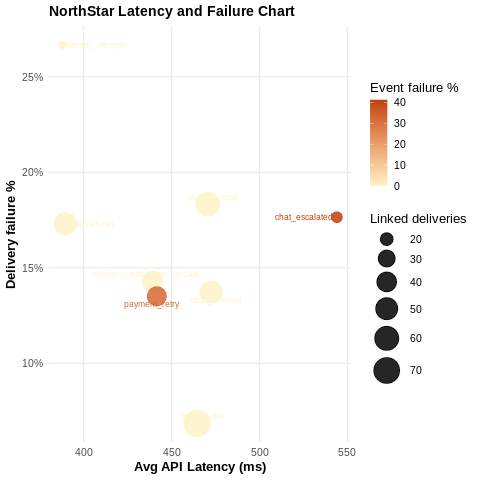

In [91]:

%%R

ggplot(
  nstar_app_performance,
  aes(
    x = average_response_time,
    y = failed_delivery_amount,
    size = linked_deliveries,
    colour = event_failure
  )
) +
  geom_point(
      alpha = 0.85
) +
  geom_text_repel(
      aes(label = event_type),
      size = 3,
      show.legend = FALSE
) +
  scale_colour_gradient(
      low = "#FEF3C7",
      high = "#C2410C"
) +
  scale_size_continuous(
      range = c(3, 12),
      labels = comma) +
  scale_x_continuous(
      labels = comma) +
  scale_y_continuous(
      labels = function(x) paste0(x, "%")) +
  labs(
    title = "NorthStar Latency and Failure Chart",
    x = "Avg API Latency (ms)",
    y = "Delivery failure %",
    size = "Linked deliveries",
    colour = "Event failure %"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold")
  )


5.2. R statistical

In [94]:
%%R

cor_test_q1 <- cor.test(
  nstar_app_performance$average_response_time,
  nstar_app_performance$event_failure,
  use = "complete.obs",
  method = "pearson"
)
cor_test_q1



	Pearson's product-moment correlation

data:  nstar_app_performance$average_response_time and nstar_app_performance$event_failure
t = 1.7468, df = 6, p-value = 0.1313
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.2099704  0.9121044
sample estimates:
      cor 
0.5806098 



6. SQL Query 3

In [104]:
%%R

nstar_fleet_assessment <- sqldf("

SELECT

    veh.vehicle_type,
    veh.maintenance_status,

    COUNT(deliv.delivery_id)
      AS delivery_total,

    AVG(
        CASE
        WHEN deliv.delivery_status = 'Failed'
        THEN 1.0
        ELSE 0
        END
      ) * 100
    AS delivery_failure_n,

    AVG(
        CASE
        WHEN deliv.delivery_status = 'Delayed'
        THEN 1.0
        ELSE 0
        END
      ) * 100
    AS delivery_delay_n,

    AVG(veh.battery_health_pct)
    AS battery_health_mean,

    AVG(deliv.manual_route_override_count)
    AS route_override_mean,

    AVG(deliv.fuel_or_charge_cost)
    AS ops_costs_mean

FROM deliveries_df AS deliv

LEFT JOIN vehicles_df AS veh
    ON deliv.vehicle_id = veh.vehicle_id

WHERE veh.vehicle_type IS NOT NULL
  AND veh.maintenance_status IS NOT NULL

GROUP BY
   veh.vehicle_type,
   veh.maintenance_status
")

In [ ]:
%%R
nstar_fleet_assessment

6.1. Visualisation

In [ ]:
%%R


q2_long <- nstar_fleet_assessment %>%
  tidyr::pivot_longer(
    cols = c(delivery_failure_n, delivery_delay_n),
    names_to = "metric",
    values_to = "percentage"
  )

ggplot(q2_long, aes(x = vehicle_type, y = percentage, fill = metric)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~maintenance_status) +
  labs(
    title = "Vehicle Performance: Failure and Delay",
    x = "Vehicle Type",
    y = "Percentage %",
    fill = "Metric"
  )

6.2. R stats

In [ ]:
%%R
#looking at how failure rate and vehicle type are related
anova_q2 <- aov(delivery_failure_n ~ vehicle_type, data = nstar_fleet_assessment)
summary(anova_q2)
